# A. Import AUTOECONSENTIMENT

In [1]:
import os
import pandas as pd
import yaml
from auto_econ_sentiment.pipeline import AutoEconSentiment
from auto_econ_sentiment.utils.load_yaml import load_yaml_config

# Ensure we are in the project root if running from notebooks directory
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

#print(f"Current working directory: {os.getcwd()}")

## A.1 Synthetic example

In [2]:
# Create synthetic data for demonstration
data = {
    "text": [
        "Economic growth remains robust despite global challenges. The central bank is committed to price stability. However, uncertainties persist regarding geopolitical tensions.", 
        "Inflationary pressures have eased slightly, but remain above target. Recent indicators suggest a softening in labor markets.",
        "Our latest projections indicate a moderate recovery. However, uncertainties persist regarding geopolitical tensions.",
        "The committee decided to maintain interest rates at their current levels to support ongoing economic expansion.",
        "Economic activity increased fast while maintaining high employment and strong consumer confidence.",
        "Slower growth and weak demand were observed in the second half of the year, leading to low inflation."
    ],
    "date": ["2024-01-01", "2024-02-01", "2024-03-01", "2024-04-01", "2024-05-01", "2024-06-01"]
}
df_demo = pd.DataFrame(data)
csv_demo_path = "data/temp/demo_data.csv"
os.makedirs("data/temp", exist_ok=True)
df_demo.to_csv(csv_demo_path, index=False)
df_demo.head()

,text,date
0,Economic growth remains robust despite global ...,2024-01-01
1,"Inflationary pressures have eased slightly, bu...",2024-02-01
2,Our latest projections indicate a moderate rec...,2024-03-01
3,The committee decided to maintain interest rat...,2024-04-01
4,Economic activity increased fast while maintai...,2024-05-01


# 1. Run autoecon sentiment
## 1.A Initialize autoecon sentiment

In [3]:
# Initialize AutoEconSentiment
analyzer = AutoEconSentiment(
    import_file_path=csv_demo_path,
    text_column="text",
    date_column="date",
    export_path="data/temp/lexical_results"
)
# Load data
df_raw = analyzer.load_data()
df_raw.head(2)

,text,date
0,Economic growth remains robust despite global ...,2024-01-01
1,"Inflationary pressures have eased slightly, bu...",2024-02-01


## 1.B Real-world example: FOMC Speeches and Statements

Now let's use a larger dataset that's included in the repository as a Parquet file. This dataset contains FOMC statements and speeches starting from 1994.

In [5]:
# Path to the parquet file
parquet_path = "data/raw/basic_tests/statements_speeches.parquet.gzip"

# Initialize AutoEconSentiment with real data
analyzer_real = AutoEconSentiment(
    import_file_path=parquet_path,
    text_column="text",
    date_column="date",
    export_path="data/temp/fomc_lexical_results"
)

# Load data
df_fomc = analyzer_real.load_data()
print(f"Loaded {len(df_fomc)} rows from {parquet_path}")

# Switch the main analyzer to use real data for subsequent cleaning and analysis steps
analyzer = analyzer_real
df_fomc.head(2)

Loaded 1931 rows from data/raw/basic_tests/statements_speeches.parquet.gzip


,Unnamed: 0.1,Unnamed: 0,date,text,type,event,link,title,speaker,text_len,release_date
0,245,0,1994-02-04,Chairman Alan Greenspan announced today that t...,Policy Statement,Policy Statement,https://www.federalreserve.gov/fomc/19940322de...,None,None,NaN,1994-02-04
1,246,1,1994-03-22,Chairman Alan Greenspan announced today that t...,Policy Statement,Policy Statement,https://www.federalreserve.gov/fomc/19940204de...,None,None,NaN,1994-03-22


## 1.1 Clean

In [6]:
# Clean data
# We'll use a basic cleaning configuration
clean_config = {
    "clean_html": True,
    "clean_numbers_percentages": True,
    "remove_headers": [],
    "tokenize": True,
    "stem": True
}

df_clean, df_sentences = analyzer.clean_data(clean_config=clean_config)
df_clean.head()

Stemming tokens: 100%|██████████| 1931/1931 [00:21<00:00, 91.78it/s] 


ValueError: too many values to unpack (expected 2)

## 1.2 Create sentiment

In [ ]:
# Run Lexical Sentiment Analysis
# We'll use a few dictionaries and both aggregation methods
dictionaries = {"unstemmed": ["correa", "hubert", "lm", "hiv"], "stemmed": ["ap"]}
aggregation_methods = ["allwords", "posneg"]

df_sent_lexical = analyzer.analyze_sentiment_lexical(
    dictionaries=dictionaries,
    aggregation_methods=aggregation_methods
)

# Show a sample of the results
df_sent_lexical.head()

Lexical Methods:  40%|████      | 2/5 [00:00<00:00,  5.22it/s]/Users/cory/Desktop/auto-econ-sentiment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:1378: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(
/Users/cory/Desktop/auto-econ-sentiment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:1378: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(
Lexical Methods: 100%|██████████| 5/5 [00:00<00:00,  5.17it/s]


,correa_counttoken_positive_allwords,correa_counttoken_negative_allwords,correa_words_positive_allwords,correa_words_negative_allwords,correa_counttoken_total_allwords,correa_sentiment_allwords,correa_counttoken_positive_posneg,correa_counttoken_negative_posneg,correa_words_positive_posneg,correa_words_negative_posneg,...,ap_counttoken_negative_allwords_stem,ap_words_positive_allwords_stem,ap_words_negative_allwords_stem,ap_counttoken_total_allwords_stem,ap_sentiment_allwords_stem,ap_counttoken_positive_posneg_stem,ap_counttoken_negative_posneg_stem,ap_words_positive_posneg_stem,ap_words_negative_posneg_stem,ap_sentiment_posneg_stem
id_text,,,,,,,,,,,,,,,,,,,,,
1,0,1,{},{'challenges': 1},17,0.941176,0,1,{},{'challenges': 1},...,0,{},{},17,1.0,0,0,{},{},1.0
2,0,0,{},{},12,1.000000,0,0,{},{},...,0,{},{},12,1.0,0,0,{},{},1.0
3,1,0,{'recovery': 1},{},10,1.100000,1,0,{'recovery': 1},{},...,0,{},{},10,1.0,0,0,{},{},1.0
4,0,0,{},{},10,1.000000,0,0,{},{},...,0,{},{},10,1.0,0,0,{},{},1.0
5,0,0,{},{},10,1.000000,0,0,{},{},...,0,"{'increas': 1, 'fast': 1, 'strong': 1, 'high': 1}",{},10,1.4,4,0,"{'increas': 1, 'fast': 1, 'strong': 1, 'high': 1}",{},2.0


## 2. Understanding Lexical Results

The `analyze_sentiment_lexical` method produces several columns for each dictionary-method-text combination:
- `counttoken_positive`: Number of positive words found.
- `counttoken_negative`: Number of negative words found.
- `words_positive`: A dictionary of positive words and their frequencies.
- `words_negative`: A dictionary of negative words and their frequencies.
- `sentiment`: The calculated sentiment score.

### Aggregation Methods:
- **posneg**: $1 + \frac{pos - neg}{pos + neg}$
  - Standardized between 0 and 2, where 1.0 is neutral.
  - It ignores the total size of the document, focusing only on the balance of sentiment words.
- **all**: $1 + \frac{pos - neg}{total\_tokens}$
  - Uses total document tokens in the denominator.
  - This accounts for the intensity/density of sentiment relative to the whole text.

## 2.A Show all sentiment measures

In [ ]:
# Exploring specific sentiment scores
sentiment_columns = [col for col in df_sent_lexical.columns if 'sentiment' in col]
df_sent_lexical[sentiment_columns].head()

,correa_sentiment_allwords,correa_sentiment_posneg,hubert_sentiment_allwords,hubert_sentiment_posneg,lm_sentiment_allwords,lm_sentiment_posneg,hiv_sentiment_allwords,hiv_sentiment_posneg,ap_sentiment_allwords_stem,ap_sentiment_posneg_stem
id_text,,,,,,,,,,
1,0.941176,0.0,1.0,1.0,1.0,1.0,1.117647,2.0,1.0,1.0
2,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0
3,1.100000,2.0,1.0,1.0,0.9,0.0,1.100000,2.0,1.0,1.0
4,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0
5,1.000000,1.0,1.4,2.0,1.1,2.0,1.000000,1.0,1.4,2.0


In [ ]:
df_sent_lexical[sentiment_columns].describe().round(1)

,correa_sentiment_allwords,correa_sentiment_posneg,hubert_sentiment_allwords,hubert_sentiment_posneg,lm_sentiment_allwords,lm_sentiment_posneg,hiv_sentiment_allwords,hiv_sentiment_posneg,ap_sentiment_allwords_stem,ap_sentiment_posneg_stem
count,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
mean,1.0,1.0,1.0,1.0,1.0,0.9,1.0,1.2,1.0,1.0
std,0.1,0.6,0.2,0.6,0.1,0.6,0.1,0.8,0.2,0.6
min,0.9,0.0,0.7,0.0,0.9,0.0,0.9,0.0,0.8,0.0
25%,1.0,1.0,1.0,1.0,0.9,0.8,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0,1.0,1.0,1.1,1.8,1.0,1.0
max,1.1,2.0,1.4,2.0,1.1,2.0,1.1,2.0,1.4,2.0


## 2.1 Show example of sentiment and keywords

In [ ]:
df_sent_lexical_text = pd.merge(df_clean[['id_text', 'text','date']], df_sent_lexical, on = 'id_text')
df_sent_lexical_text.head(2)

NameError: name 'df_clean' is not defined

### 2.1.A Create function to compare

In [ ]:
def show_dictionary_example(dictionary):
    return df_sent_lexical_text.set_index(['date','text']).filter(regex=dictionary).filter(regex="words")

### 2.1.1 Compare

In [ ]:
show_dictionary_example("correa")

NameError: name 'df_sent_lexical_text' is not defined

In [ ]:
show_dictionary_example("lm")

lm_counttoken_positive_allwords  \
date       text                                                                                  
1994-02-04 Chairman Alan Greenspan announced today that th...                                0   
1994-03-22 Chairman Alan Greenspan announced today that th...                                1   
1994-04-18 Chairman Alan Greenspan announced today that th...                                0   
1994-05-17 The Federal Reserve today announced two actions...                                2   
1994-08-16 The Federal Reserve announced today the followi...                                1   
...                                                                                        ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...                               28   
2023-01-19  Inflation has declined in recent months, which...                               14   
2023-01-10  Governor Bowman presented identical remarks to...                               41   
            I will address three main points. First, the F...                               27   
2023-01-06  I am particularly pleased to be here today for...                               20   

                                                               lm_counttoken_negative_allwords  \
date       text                                                                                  
1994-02-04 Chairman Alan Greenspan announced today that th...                                0   
1994-03-22 Chairman Alan Greenspan announced today that th...                                1   
1994-04-18 Chairman Alan Greenspan announced today that th...                                0   
1994-05-17 The Federal Reserve today announced two actions...                                0   
1994-08-16 The Federal Reserve announced today the followi...                                1   
...                                                                                        ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...                               39   
2023-01-19  Inflation has declined in recent months, which...                               70   
2023-01-10  Governor Bowman presented identical remarks to...                               40   
            I will address three main points. First, the F...                                4   
2023-01-06  I am particularly pleased to be here today for...                               58   

                                                                                      lm_words_positive_allwords  \
date       text                                                                                                    
1994-02-04 Chairman Alan Greenspan announced today that th...                                                 {}   
1994-03-22 Chairman Alan Greenspan announced today that th...                                     {'enhance': 1}   
1994-04-18 Chairman Alan Greenspan announced today that th...                                                 {}   
1994-05-17 The Federal Reserve today announced two actions...                   {'effective': 1, 'favorable': 1}   
1994-08-16 The Federal Reserve announced today the followi...                                    {'strength': 1}   
...                                                                                                          ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...  {'better': 1, 'desirable': 1, 'despite': 1, 'e...   
2023-01-19  Inflation has declined in recent months, which...  {'benefited': 1, 'despite': 1, 'enable': 1, 'g...   
2023-01-10  Governor Bowman presented identical remarks to...  {'achieve': 2, 'achieves': 1, 'better': 1, 'de...   
            I will address three main points. First, the F...  {'achieve': 2, 'achieving': 1, 'confident': 1,...   
2023-01-06  I am particularly pleased to be here today for...  {'better': 5, 'boosted': 1, 'despite': 2, 'eas...   

    

In [ ]:
show_dictionary_example("hubert")

hubert_counttoken_positive_allwords  \
date       text                                                                                      
1994-02-04 Chairman Alan Greenspan announced today that th...                                    2   
1994-03-22 Chairman Alan Greenspan announced today that th...                                    2   
1994-04-18 Chairman Alan Greenspan announced today that th...                                    2   
1994-05-17 The Federal Reserve today announced two actions...                                    2   
1994-08-16 The Federal Reserve announced today the followi...                                    1   
...                                                                                            ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...                                   19   
2023-01-19  Inflation has declined in recent months, which...                                   21   
2023-01-10  Governor Bowman presented identical remarks to...                                   19   
            I will address three main points. First, the F...                                    2   
2023-01-06  I am particularly pleased to be here today for...                                   15   

                                                               hubert_counttoken_negative_allwords  \
date       text                                                                                      
1994-02-04 Chairman Alan Greenspan announced today that th...                                    0   
1994-03-22 Chairman Alan Greenspan announced today that th...                                    0   
1994-04-18 Chairman Alan Greenspan announced today that th...                                    0   
1994-05-17 The Federal Reserve today announced two actions...                                    0   
1994-08-16 The Federal Reserve announced today the followi...                                    0   
...                                                                                            ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...                                    9   
2023-01-19  Inflation has declined in recent months, which...                                    9   
2023-01-10  Governor Bowman presented identical remarks to...                                    9   
            I will address three main points. First, the F...                                    1   
2023-01-06  I am particularly pleased to be here today for...                                    3   

                                                                                  hubert_words_positive_allwords  \
date       text                                                                                                    
1994-02-04 Chairman Alan Greenspan announced today that th...                                    {'increase': 2}   
1994-03-22 Chairman Alan Greenspan announced today that th...                                    {'increase': 2}   
1994-04-18 Chairman Alan Greenspan announced today that th...                                    {'increase': 2}   
1994-05-17 The Federal Reserve today announced two actions...                                    {'increase': 2}   
1994-08-16 The Federal Reserve announced today the followi...                                        {'high': 1}   
...                                                                                                          ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...  {'increase': 5, 'accelerated': 1, 'acceleratin...   
2023-01-19  Inflation has declined in recent months, which...  {'increase': 2, 'increased': 1, 'increases': 8...   
2023-01-10  Governor Bowman presented identical remarks to...  {'increase': 1, 'increasing': 1, 'increases': ...   
            I will address three main points. First, the F...                                        {'high': 2}   
2023-01-06  I am 

In [ ]:
show_dictionary_example("hiv")

hiv_counttoken_positive_allwords  \
date       text                                                                                   
1994-02-04 Chairman Alan Greenspan announced today that th...                                 0   
1994-03-22 Chairman Alan Greenspan announced today that th...                                 1   
1994-04-18 Chairman Alan Greenspan announced today that th...                                 0   
1994-05-17 The Federal Reserve today announced two actions...                                 3   
1994-08-16 The Federal Reserve announced today the followi...                                 3   
...                                                                                         ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...                                36   
2023-01-19  Inflation has declined in recent months, which...                                54   
2023-01-10  Governor Bowman presented identical remarks to...                                50   
            I will address three main points. First, the F...                                60   
2023-01-06  I am particularly pleased to be here today for...                                43   

                                                               hiv_counttoken_negative_allwords  \
date       text                                                                                   
1994-02-04 Chairman Alan Greenspan announced today that th...                                 0   
1994-03-22 Chairman Alan Greenspan announced today that th...                                 2   
1994-04-18 Chairman Alan Greenspan announced today that th...                                 0   
1994-05-17 The Federal Reserve today announced two actions...                                 1   
1994-08-16 The Federal Reserve announced today the followi...                                 1   
...                                                                                         ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...                                42   
2023-01-19  Inflation has declined in recent months, which...                                58   
2023-01-10  Governor Bowman presented identical remarks to...                                30   
            I will address three main points. First, the F...                                 7   
2023-01-06  I am particularly pleased to be here today for...                                67   

                                                                                     hiv_words_positive_allwords  \
date       text                                                                                                    
1994-02-04 Chairman Alan Greenspan announced today that th...                                                 {}   
1994-03-22 Chairman Alan Greenspan announced today that th...                                     {'enhance': 1}   
1994-04-18 Chairman Alan Greenspan announced today that th...                                                 {}   
1994-05-17 The Federal Reserve today announced two actions...  {'accommodation': 1, 'effective': 1, 'favorabl...   
1994-08-16 The Federal Reserve announced today the followi...   {'foster': 1, 'sufficient': 1, 'utilization': 1}   
...                                                                                                          ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...  {'ample': 1, 'asset': 1, 'compensation': 2, 'c...   
2023-01-19  Inflation has declined in recent months, which...  {'accommodation': 3, 'adjustment': 1, 'aggrega...   
2023-01-10  Governor Bowman presented identical remarks to...  {'ability': 1, 'achieve': 2, 'availability': 1...   
            I will address three main points. First, the F...  {'achieve': 2, 'commitment': 1, 'confident': 1...   
2023-01-06  I am particularly pleased to be here today for...  {'ability': 4, 'accessible': 1, 

In [ ]:
show_dictionary_example("ap")

ap_counttoken_positive_allwords_stem  \
date       text                                                                                       
1994-02-04 Chairman Alan Greenspan announced today that th...                                     2   
1994-03-22 Chairman Alan Greenspan announced today that th...                                     2   
1994-04-18 Chairman Alan Greenspan announced today that th...                                     2   
1994-05-17 The Federal Reserve today announced two actions...                                     2   
1994-08-16 The Federal Reserve announced today the followi...                                     1   
...                                                                                             ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...                                    10   
2023-01-19  Inflation has declined in recent months, which...                                    18   
2023-01-10  Governor Bowman presented identical remarks to...                                    16   
            I will address three main points. First, the F...                                     2   
2023-01-06  I am particularly pleased to be here today for...                                    14   

                                                               ap_counttoken_negative_allwords_stem  \
date       text                                                                                       
1994-02-04 Chairman Alan Greenspan announced today that th...                                     0   
1994-03-22 Chairman Alan Greenspan announced today that th...                                     0   
1994-04-18 Chairman Alan Greenspan announced today that th...                                     0   
1994-05-17 The Federal Reserve today announced two actions...                                     0   
1994-08-16 The Federal Reserve announced today the followi...                                     0   
...                                                                                             ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...                                    11   
2023-01-19  Inflation has declined in recent months, which...                                     4   
2023-01-10  Governor Bowman presented identical remarks to...                                     7   
            I will address three main points. First, the F...                                     1   
2023-01-06  I am particularly pleased to be here today for...                                     3   

                                                                                 ap_words_positive_allwords_stem  \
date       text                                                                                                    
1994-02-04 Chairman Alan Greenspan announced today that th...                                     {'increas': 2}   
1994-03-22 Chairman Alan Greenspan announced today that th...                                     {'increas': 2}   
1994-04-18 Chairman Alan Greenspan announced today that th...                                     {'increas': 2}   
1994-05-17 The Federal Reserve today announced two actions...                                     {'increas': 2}   
1994-08-16 The Federal Reserve announced today the followi...                                        {'high': 1}   
...                                                                                                          ...   
2023-01-20  Thank you, Ben, and thank you to the Council o...  {'increas': 5, 'fast': 1, 'strong': 2, 'high': 2}   
2023-01-19  Inflation has declined in recent months, which...                         {'increas': 11, 'high': 7}   
2023-01-10  Governor Bowman presented identical remarks to...             {'increas': 4, 'strong': 5, 'high': 7}   
            I will address three main points. First, the F...                                        {'high

## Visualizing Sentiment Trends

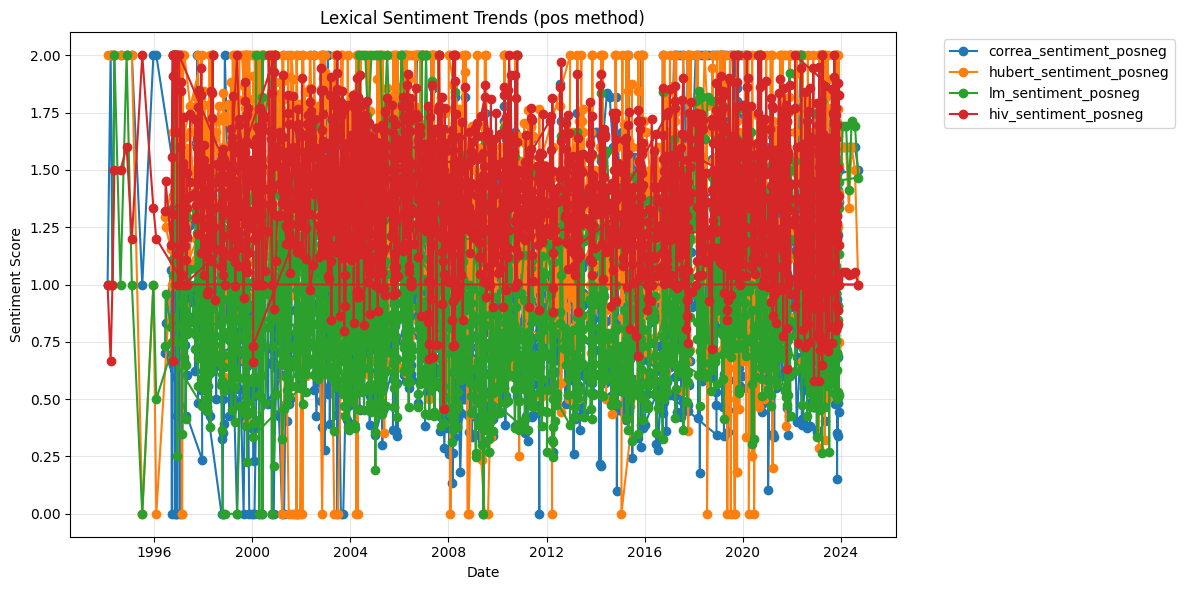

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_final = df_sent_lexical_text

plt.figure(figsize=(12, 6))
for col in [c for c in sentiment_columns if 'pos' in c and 'stem' not in c]:
    plt.plot(df_final['date'], df_final[col], label=col, marker='o')

plt.title('Lexical Sentiment Trends (pos method)')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Loading Previously Exported Results

Once the pipeline has been run, the results are stored in the export path. You can load them directly for further analysis without re-running the analysis.

In [ ]:
# # Load the full sentiment results
# export_path = "data/temp/lexical_results"
# df_results = pd.read_csv(f"{export_path}/sentiment_all_results.csv")

# # Load just the lexical components
# df_lexical_only = pd.read_csv(f"{export_path}/sentiment_lexical.csv")

# print(f"Loaded results shape: {df_results.shape}")
# df_results.head()

## Conclusion

In this notebook, we demonstrated how the `AutoEconSentiment` library simplifies lexical sentiment analysis. By providing a unified interface for multiple dictionaries and aggregation methods, it allows researchers to easily compare different sentiment metrics and robustly analyze economic texts.